# Classification Models Comparison

This notebook compares four popular classification algorithms:
- Support Vector Machine (SVM)
- Decision Tree
- K-Nearest Neighbors (KNN)
- Naive Bayes

We will evaluate their performance using various metrics and analyze their suitability for different classification tasks.

## Step 1: Import Required Libraries

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report, 
                             log_loss, roc_curve, auc, roc_auc_score)

# Classification models
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load and Explore the Dataset

We'll use the Breast Cancer Wisconsin dataset - a common binary classification problem to detect malignant or benign tumors.

In [18]:
# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Create DataFrame for better visualization
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nTarget Distribution:")
print(df['target'].value_counts())
print("\nClass Labels:", data.target_names)

Dataset Shape: (569, 31)

First few rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  wor

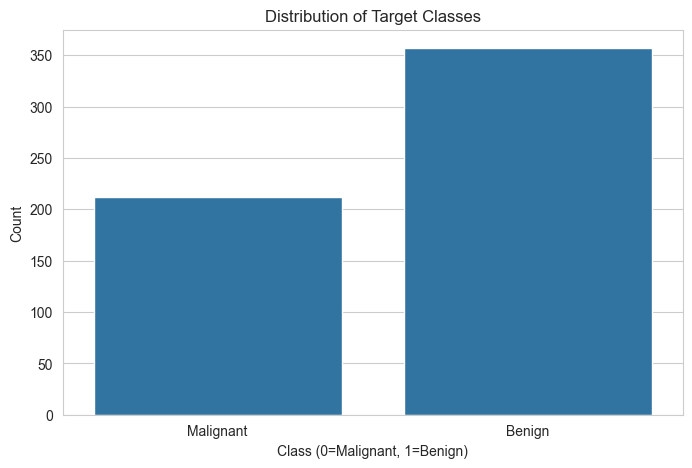


Dataset Statistics:
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             

In [19]:
# Visualize target distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='target', data=df)
plt.title('Distribution of Target Classes')
plt.xlabel('Class (0=Malignant, 1=Benign)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Malignant', 'Benign'])
plt.show()

# Basic statistics
print("\nDataset Statistics:")
print(df.describe())

## Step 3: Data Preprocessing

Split the data into training and testing sets, and apply feature scaling.

In [20]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

# Feature Scaling (important for SVM and KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData preprocessing completed!")

Training set size: (398, 30)
Testing set size: (171, 30)

Data preprocessing completed!


## Step 4: Build and Train Classification Models

### 4.1 Support Vector Machine (SVM)

In [21]:
# Train SVM model
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Make predictions
svm_pred = svm_model.predict(X_test_scaled)
svm_pred_proba = svm_model.predict_proba(X_test_scaled)

print("SVM Model trained successfully!")

SVM Model trained successfully!


### 4.2 Decision Tree

In [22]:
# Train Decision Tree model
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
dt_pred = dt_model.predict(X_test)
dt_pred_proba = dt_model.predict_proba(X_test)

print("Decision Tree Model trained successfully!")

Decision Tree Model trained successfully!


### 4.3 K-Nearest Neighbors (KNN)

In [23]:
# Train KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Make predictions
knn_pred = knn_model.predict(X_test_scaled)
knn_pred_proba = knn_model.predict_proba(X_test_scaled)

print("KNN Model trained successfully!")

KNN Model trained successfully!


### 4.4 Naive Bayes

In [24]:
# Train Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

# Make predictions
nb_pred = nb_model.predict(X_test_scaled)
nb_pred_proba = nb_model.predict_proba(X_test_scaled)

print("Naive Bayes Model trained successfully!")

Naive Bayes Model trained successfully!


## Step 4.5: Decision Boundary Visualization

To visualize how each model classifies the data, we'll reduce the features to 2D using PCA and plot the decision boundaries.

In [25]:
# Reduce dimensions to 2D for visualization using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original features:", X_train_scaled.shape[1])
print("Reduced to:", X_train_pca.shape[1], "dimensions")
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", sum(pca.explained_variance_ratio_))

Original features: 30
Reduced to: 2 dimensions
Explained variance ratio: [0.45156229 0.19628669]
Total variance explained: 0.6478489770033


In [26]:
# Train models on 2D PCA data for visualization
svm_model_2d = SVC(kernel='rbf', probability=True, random_state=42)
dt_model_2d = DecisionTreeClassifier(max_depth=10, random_state=42)
knn_model_2d = KNeighborsClassifier(n_neighbors=5)
nb_model_2d = GaussianNB()

# Fit models
svm_model_2d.fit(X_train_pca, y_train)
dt_model_2d.fit(X_train_pca, y_train)
knn_model_2d.fit(X_train_pca, y_train)
nb_model_2d.fit(X_train_pca, y_train)

print("All models trained on 2D PCA data!")

All models trained on 2D PCA data!


In [27]:
# Function to plot decision boundaries
def plot_decision_boundary(model, X, y, title, ax):
    # Create mesh grid
    h = 0.02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Predict on mesh grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    
    # Plot training points
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', 
                        edgecolors='black', s=50, alpha=0.8)
    
    ax.set_xlabel('First Principal Component', fontsize=10)
    ax.set_ylabel('Second Principal Component', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    
    return scatter

print("Decision boundary plotting function created!")

Decision boundary plotting function created!


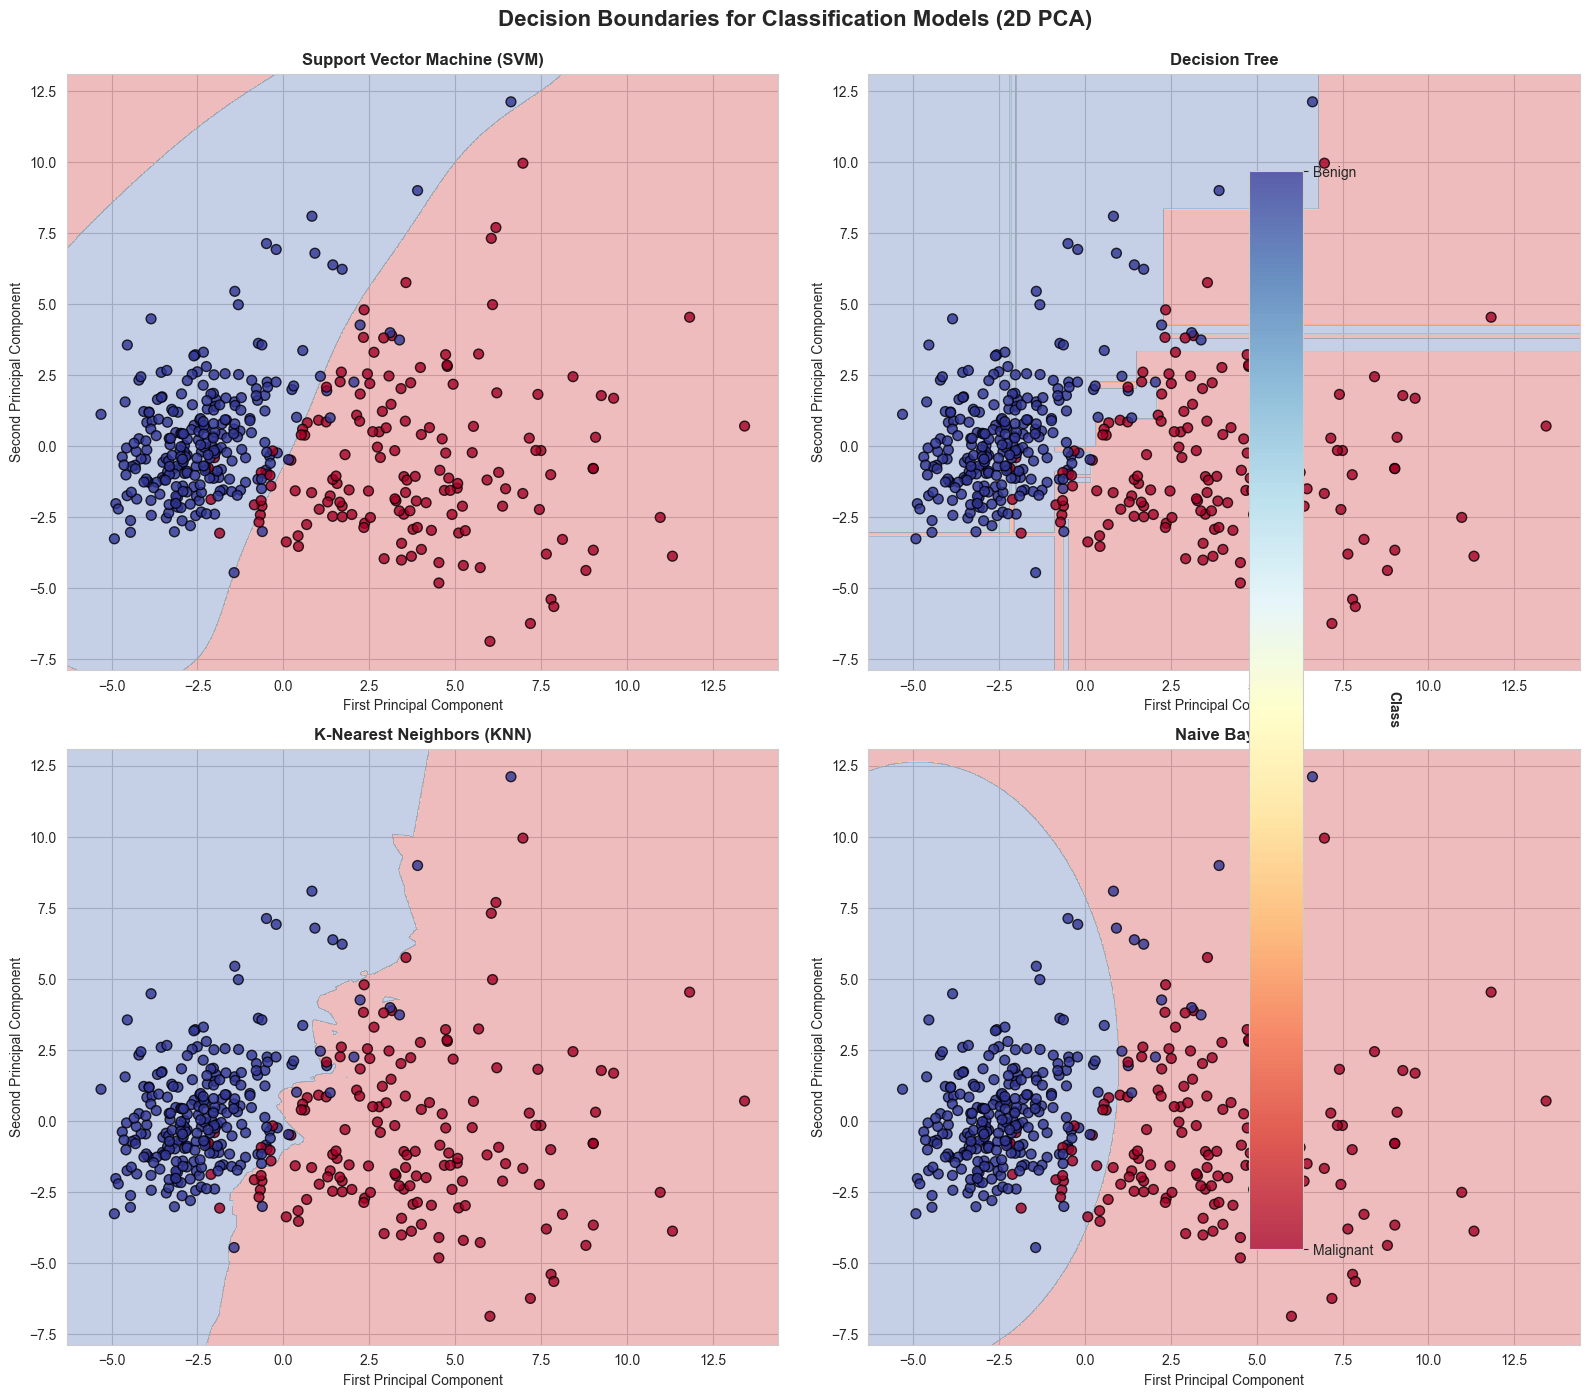

In [28]:
# Plot decision boundaries for all models
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Decision Boundaries for Classification Models (2D PCA)', 
             fontsize=16, fontweight='bold', y=0.995)

models_2d = [
    (svm_model_2d, "Support Vector Machine (SVM)"),
    (dt_model_2d, "Decision Tree"),
    (knn_model_2d, "K-Nearest Neighbors (KNN)"),
    (nb_model_2d, "Naive Bayes")
]

for idx, (model, name) in enumerate(models_2d):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    scatter = plot_decision_boundary(model, X_train_pca, y_train, name, ax)

# Add colorbar
cbar = plt.colorbar(scatter, ax=axes.ravel().tolist(), 
                    ticks=[0, 1], pad=0.01)
cbar.set_label('Class', rotation=270, labelpad=20, fontweight='bold')
cbar.ax.set_yticklabels(['Malignant', 'Benign'])

plt.tight_layout()
plt.show()

### Individual Model Classification Visualizations

Let's create separate detailed visualizations for each model showing both training and test data.

In [29]:
# Enhanced plotting function with train and test data
def plot_classification_detailed(model, X_train, y_train, X_test, y_test, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Create mesh grid
    h = 0.02
    x_min = min(X_train[:, 0].min(), X_test[:, 0].min()) - 1
    x_max = max(X_train[:, 0].max(), X_test[:, 0].max()) + 1
    y_min = min(X_train[:, 1].min(), X_test[:, 1].min()) - 1
    y_max = max(X_train[:, 1].max(), X_test[:, 1].max()) + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot training data
    ax1.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    scatter1 = ax1.scatter(X_train[:, 0], X_train[:, 1], c=y_train, 
                          cmap='RdYlBu', edgecolors='black', s=60, alpha=0.8)
    ax1.set_xlabel('First Principal Component', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Second Principal Component', fontsize=11, fontweight='bold')
    ax1.set_title(f'{title} - Training Data', fontsize=12, fontweight='bold')
    ax1.grid(alpha=0.3)
    
    # Plot test data
    ax2.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    scatter2 = ax2.scatter(X_test[:, 0], X_test[:, 1], c=y_test, 
                          cmap='RdYlBu', edgecolors='black', s=60, alpha=0.8, marker='s')
    ax2.set_xlabel('First Principal Component', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Second Principal Component', fontsize=11, fontweight='bold')
    ax2.set_title(f'{title} - Test Data', fontsize=12, fontweight='bold')
    ax2.grid(alpha=0.3)
    
    # Add colorbar
    cbar = plt.colorbar(scatter2, ax=[ax1, ax2], ticks=[0, 1])
    cbar.set_label('Class', rotation=270, labelpad=20, fontweight='bold')
    cbar.ax.set_yticklabels(['Malignant (0)', 'Benign (1)'])
    
    plt.tight_layout()
    plt.show()

print("Enhanced plotting function ready!")

Enhanced plotting function ready!


#### SVM Classification Visualization

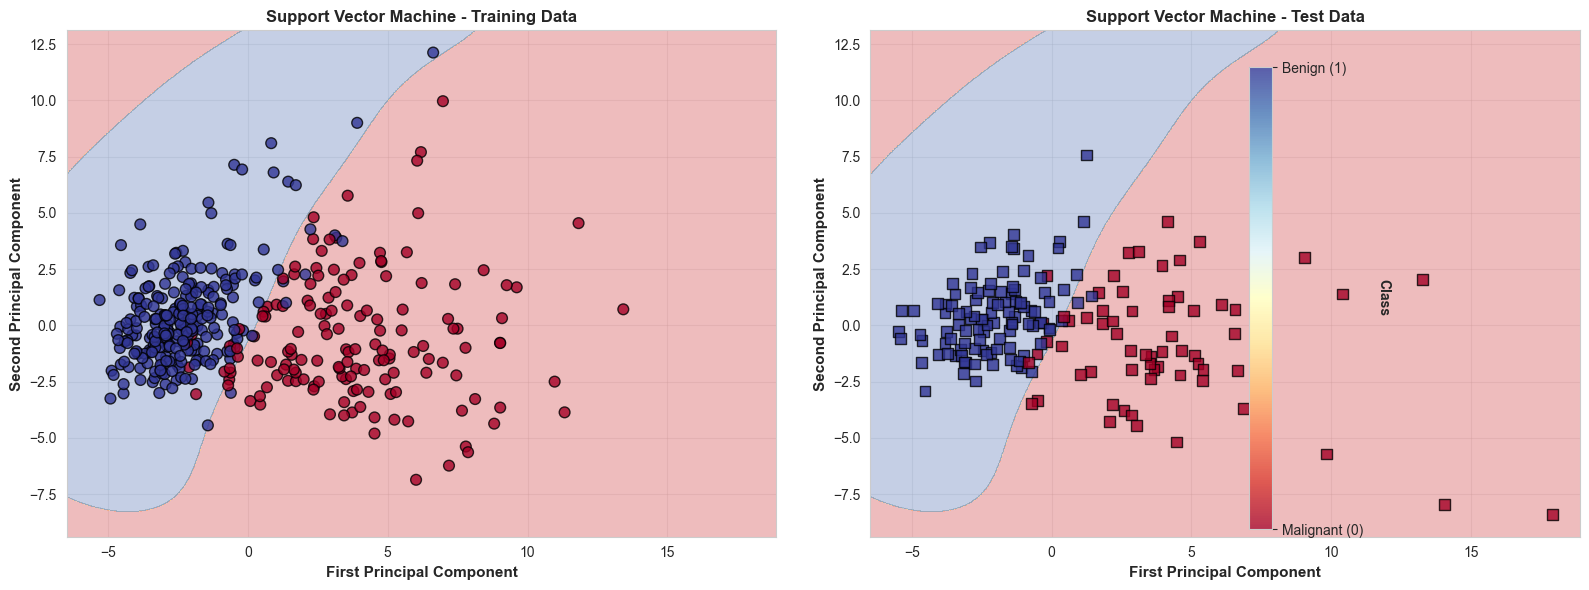

In [30]:
plot_classification_detailed(svm_model_2d, X_train_pca, y_train, 
                            X_test_pca, y_test, "Support Vector Machine")

#### Decision Tree Classification Visualization

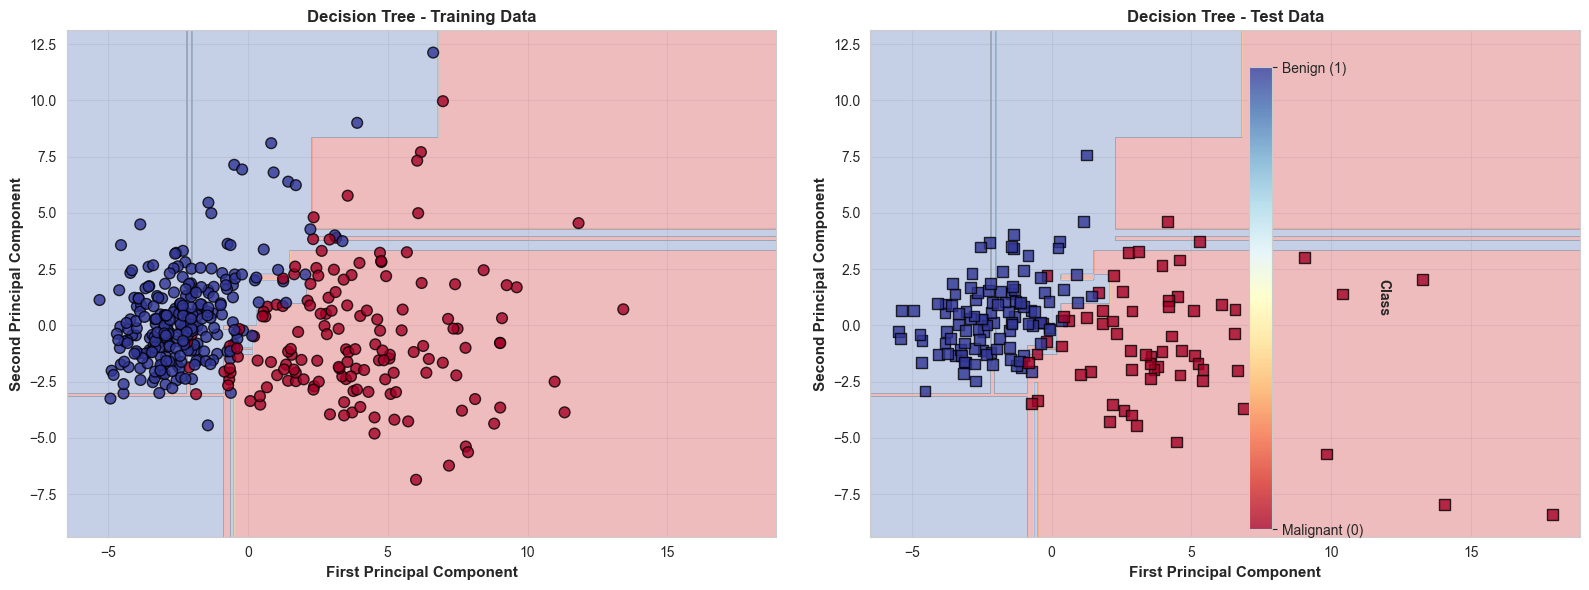

In [31]:
plot_classification_detailed(dt_model_2d, X_train_pca, y_train, 
                            X_test_pca, y_test, "Decision Tree")

#### KNN Classification Visualization

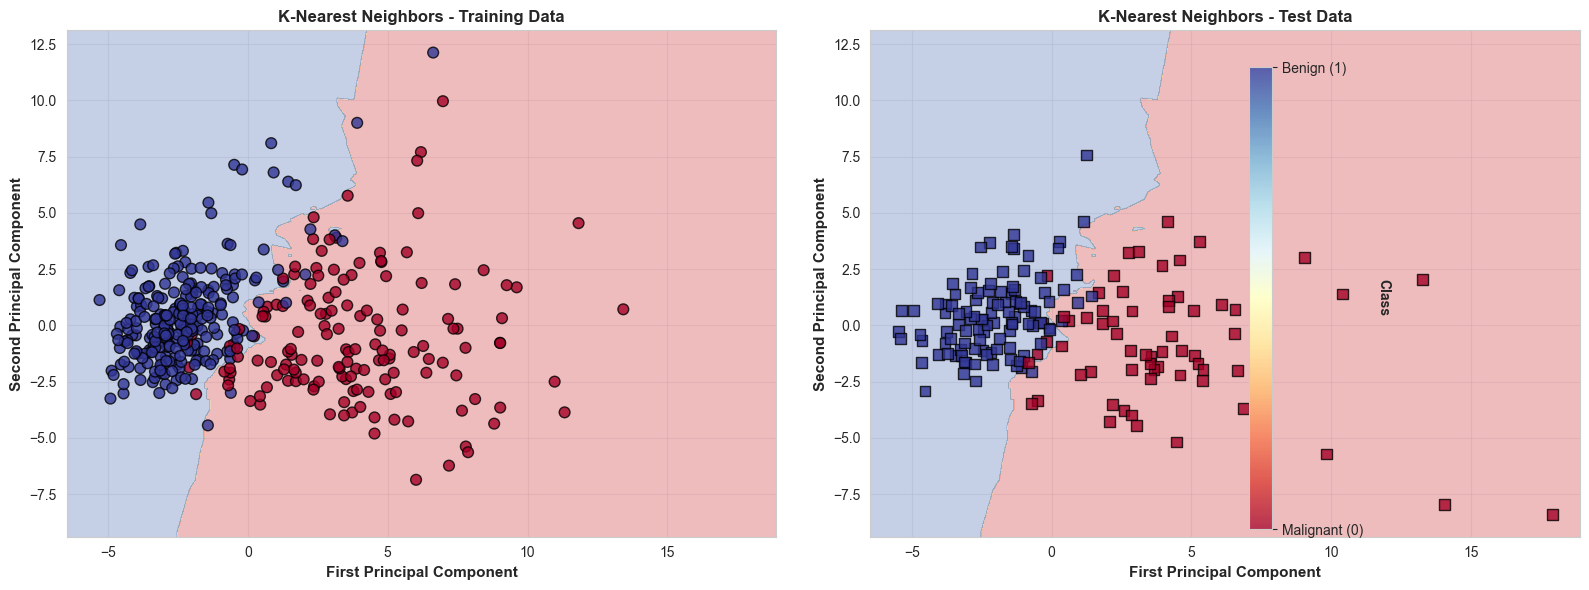

In [32]:
plot_classification_detailed(knn_model_2d, X_train_pca, y_train, 
                            X_test_pca, y_test, "K-Nearest Neighbors")

#### Naive Bayes Classification Visualization

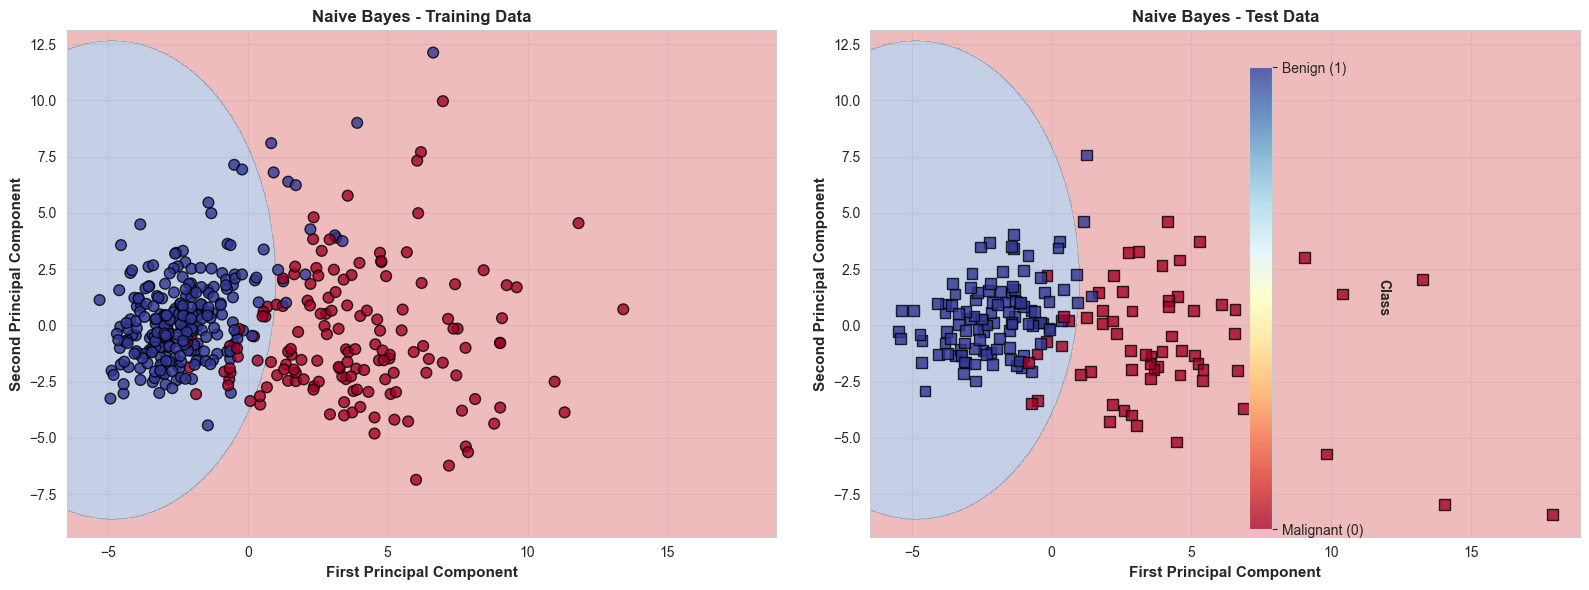

In [33]:
plot_classification_detailed(nb_model_2d, X_train_pca, y_train, 
                            X_test_pca, y_test, "Naive Bayes")

### Interpretation of Decision Boundaries

**Key Observations:**

1. **SVM**: Creates smooth, curved decision boundaries due to the RBF kernel. Shows clear separation with a margin around the boundary.

2. **Decision Tree**: Creates rectangular/axis-aligned decision boundaries due to its splitting nature. The boundaries appear as straight lines parallel to axes.

3. **KNN**: Produces irregular, localized decision boundaries that adapt to the local structure of the data. The boundaries can be quite jagged.

4. **Naive Bayes**: Assumes Gaussian distribution and creates smooth, probabilistic boundaries based on feature independence assumption.

**Note**: These visualizations use 2D PCA projections, so they capture only a portion of the total variance in the original high-dimensional data. The actual decision boundaries in the full feature space are more complex.

## Step 5: Evaluate Model Performance

Calculate all relevant metrics for each model.

In [34]:
# Function to calculate all metrics
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    loss = log_loss(y_true, y_pred_proba)
    
    print(f"\n{model_name} Performance Metrics:")
    print("="*50)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"Log Loss:  {loss:.4f}")
    
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Log Loss': loss
    }

# Evaluate all models
results = []
results.append(evaluate_model(y_test, svm_pred, svm_pred_proba, "SVM"))
results.append(evaluate_model(y_test, dt_pred, dt_pred_proba, "Decision Tree"))
results.append(evaluate_model(y_test, knn_pred, knn_pred_proba, "KNN"))
results.append(evaluate_model(y_test, nb_pred, nb_pred_proba, "Naive Bayes"))

# Create results dataframe
results_df = pd.DataFrame(results)
print("\n\nSummary of All Models:")
print("="*70)
print(results_df.to_string(index=False))


SVM Performance Metrics:
Accuracy:  0.9766
Precision: 0.9813
Recall:    0.9813
F1-Score:  0.9813
Log Loss:  0.0758

Decision Tree Performance Metrics:
Accuracy:  0.9181
Precision: 0.9346
Recall:    0.9346
F1-Score:  0.9346
Log Loss:  2.9509

KNN Performance Metrics:
Accuracy:  0.9591
Precision: 0.9386
Recall:    1.0000
F1-Score:  0.9683
Log Loss:  0.3012

Naive Bayes Performance Metrics:
Accuracy:  0.9357
Precision: 0.9364
Recall:    0.9626
F1-Score:  0.9493
Log Loss:  0.3636


Summary of All Models:
        Model  Accuracy  Precision   Recall  F1-Score  Log Loss
          SVM  0.976608   0.981308 0.981308  0.981308  0.075837
Decision Tree  0.918129   0.934579 0.934579  0.934579  2.950942
          KNN  0.959064   0.938596 1.000000  0.968326  0.301175
  Naive Bayes  0.935673   0.936364 0.962617  0.949309  0.363561


## Step 6: Visualization of Results

### 6.1 Performance Metrics Comparison

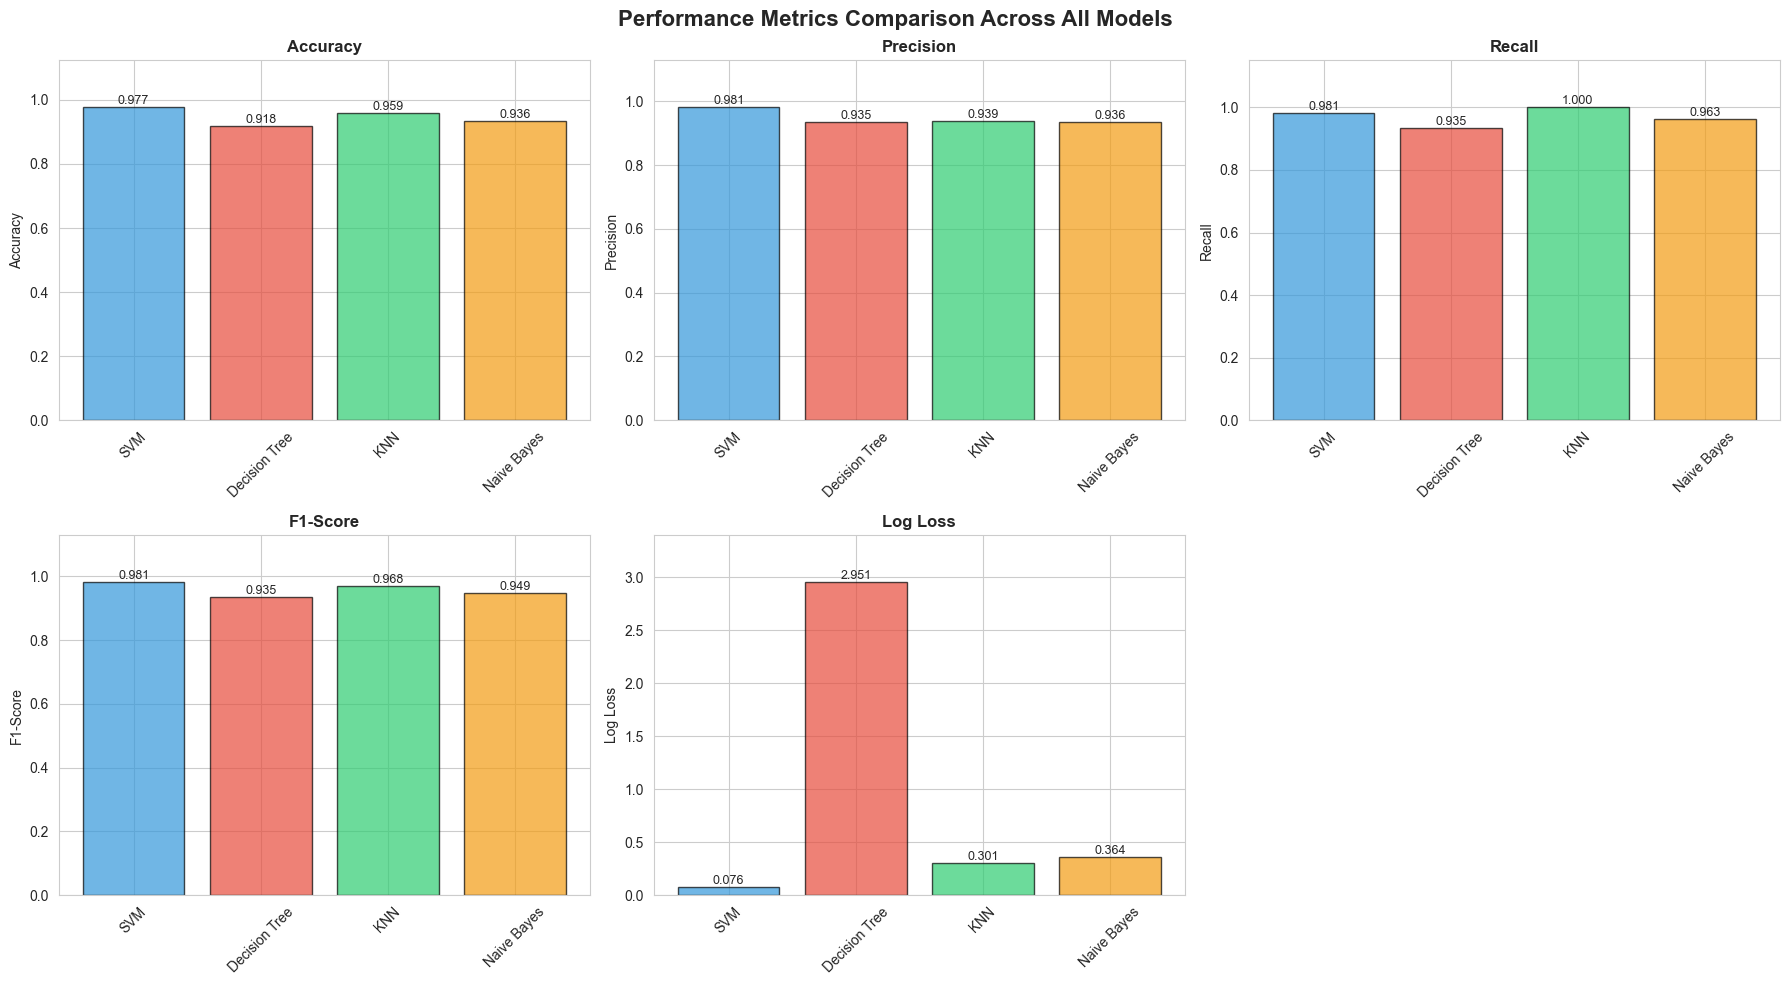

In [35]:
# Bar plot for all metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Performance Metrics Comparison Across All Models', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Log Loss']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, metric in enumerate(metrics):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    values = results_df[metric].values
    bars = ax.bar(results_df['Model'], values, color=colors, alpha=0.7, edgecolor='black')
    
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim([0, max(values) * 1.15])
    ax.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

# Remove the extra subplot
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

### 6.2 Grouped Bar Chart for Better Comparison

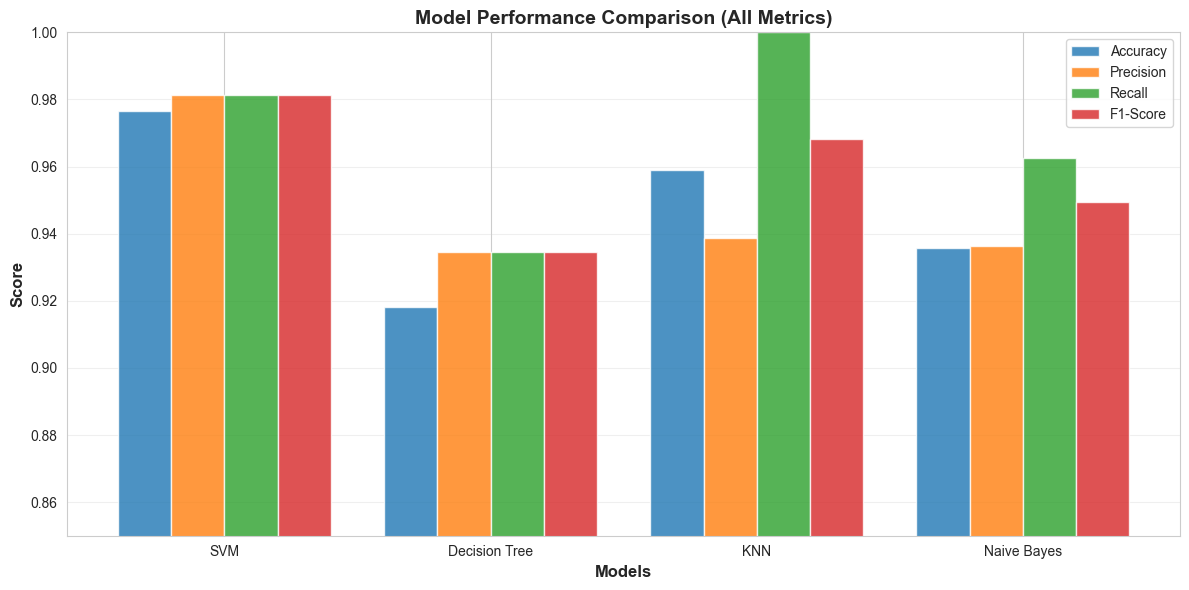

In [36]:
# Grouped bar chart (excluding Log Loss for better visualization)
metrics_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df['Model']))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

for i, metric in enumerate(metrics_plot):
    offset = width * (i - 1.5)
    ax.bar(x + offset, results_df[metric], width, label=metric, alpha=0.8)

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison (All Metrics)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'])
ax.legend()
ax.set_ylim([0.85, 1.0])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 6.3 Confusion Matrices

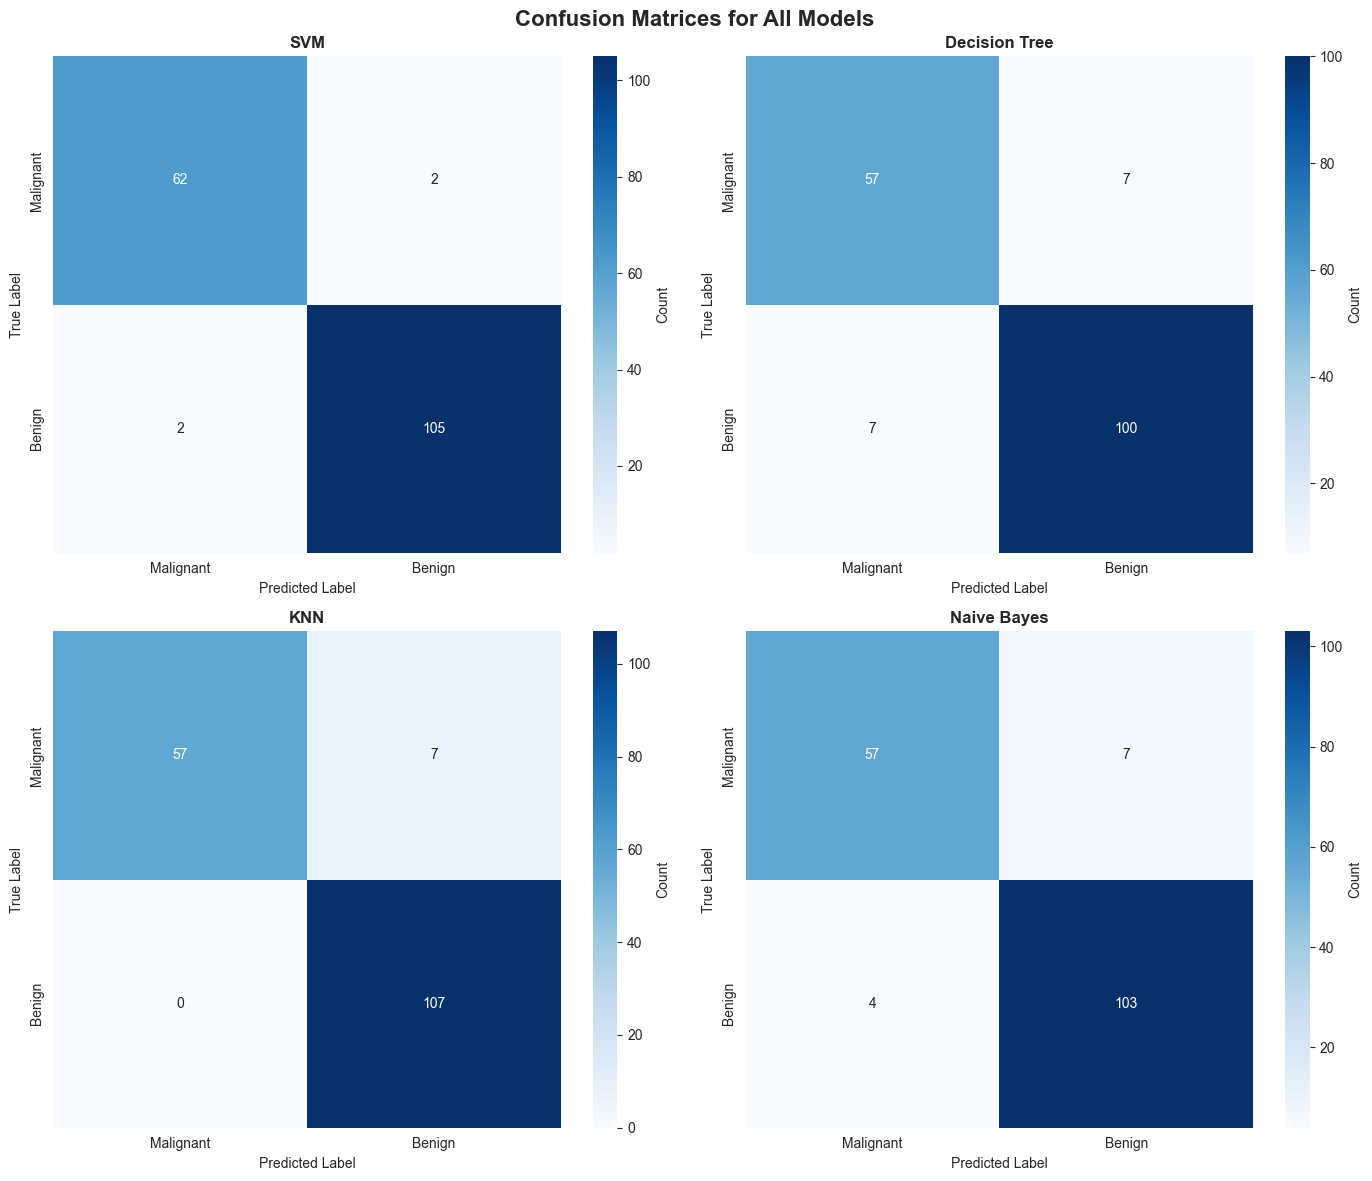

In [37]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Confusion Matrices for All Models', fontsize=16, fontweight='bold')

models_pred = [
    (svm_pred, "SVM"),
    (dt_pred, "Decision Tree"),
    (knn_pred, "KNN"),
    (nb_pred, "Naive Bayes")
]

for idx, (pred, name) in enumerate(models_pred):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                cbar_kws={'label': 'Count'})
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_xticklabels(['Malignant', 'Benign'])
    ax.set_yticklabels(['Malignant', 'Benign'])

plt.tight_layout()
plt.show()

### 6.4 ROC Curves

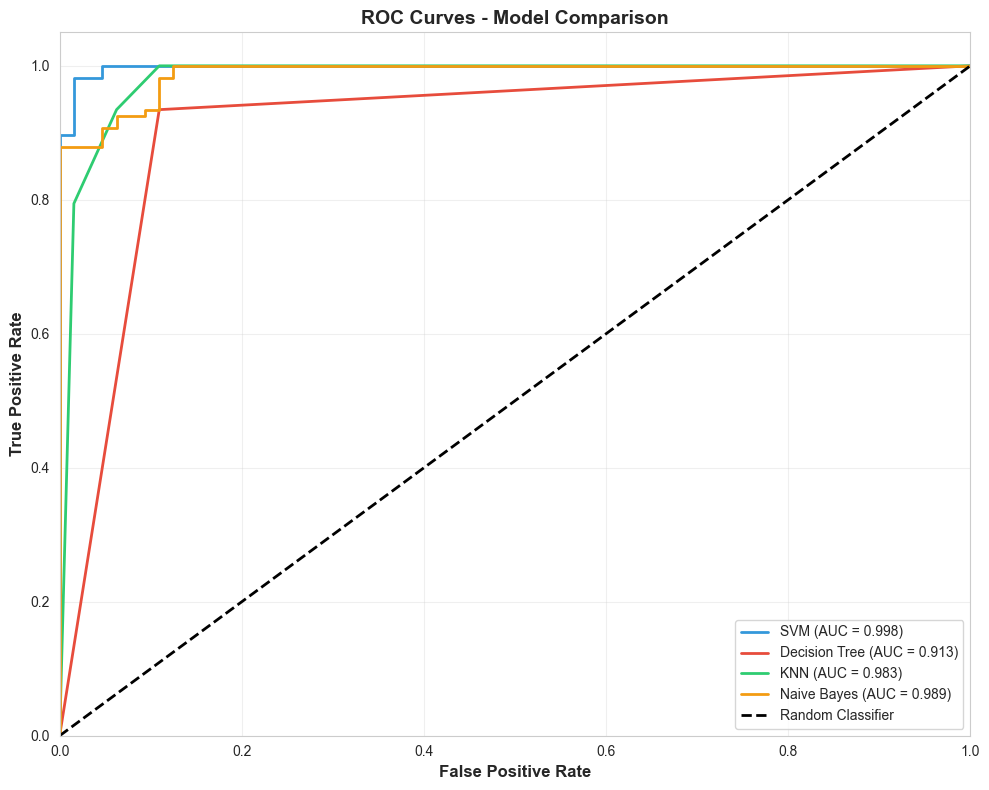

In [38]:
# Plot ROC curves for all models
plt.figure(figsize=(10, 8))

models_proba = [
    (svm_pred_proba[:, 1], "SVM"),
    (dt_pred_proba[:, 1], "Decision Tree"),
    (knn_pred_proba[:, 1], "KNN"),
    (nb_pred_proba[:, 1], "Naive Bayes")
]

colors_roc = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, (proba, name) in enumerate(models_proba):
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors_roc[idx], lw=2, 
             label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 6.5 Classification Reports

In [39]:
# Print detailed classification reports
models_list = [
    (svm_pred, "SVM"),
    (dt_pred, "Decision Tree"),
    (knn_pred, "KNN"),
    (nb_pred, "Naive Bayes")
]

for pred, name in models_list:
    print(f"\n{name} - Detailed Classification Report:")
    print("="*60)
    print(classification_report(y_test, pred, target_names=['Malignant', 'Benign']))
    print("="*60)


SVM - Detailed Classification Report:
              precision    recall  f1-score   support

   Malignant       0.97      0.97      0.97        64
      Benign       0.98      0.98      0.98       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171


Decision Tree - Detailed Classification Report:
              precision    recall  f1-score   support

   Malignant       0.89      0.89      0.89        64
      Benign       0.93      0.93      0.93       107

    accuracy                           0.92       171
   macro avg       0.91      0.91      0.91       171
weighted avg       0.92      0.92      0.92       171


KNN - Detailed Classification Report:
              precision    recall  f1-score   support

   Malignant       1.00      0.89      0.94        64
      Benign       0.94      1.00      0.97       107

    accuracy                           0.96       171
 

### 6.6 Heatmap of Performance Metrics

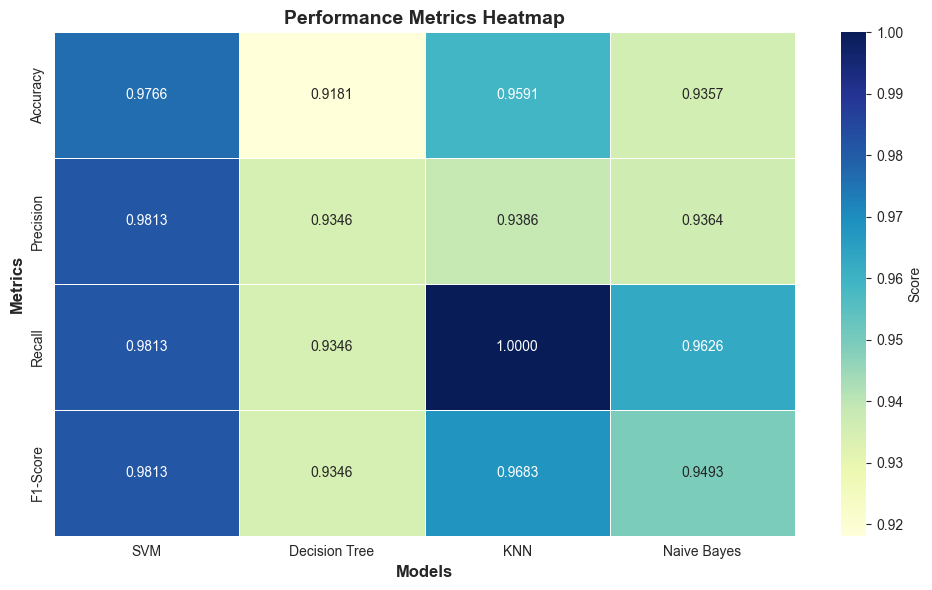

In [40]:
# Create heatmap for performance comparison
plt.figure(figsize=(10, 6))

# Prepare data for heatmap (normalize log loss for better visualization)
heatmap_data = results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].T

sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlGnBu', 
            cbar_kws={'label': 'Score'}, linewidths=0.5)
plt.title('Performance Metrics Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Models', fontsize=12, fontweight='bold')
plt.ylabel('Metrics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7: Comparative Analysis and Findings

### Summary of Results

In [41]:
# Find best performing model for each metric
print("Best Performing Models for Each Metric:")
print("="*60)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    best_model = results_df.loc[results_df[metric].idxmax(), 'Model']
    best_score = results_df[metric].max()
    print(f"{metric:12s}: {best_model:15s} ({best_score:.4f})")

print(f"{'Log Loss':12s}: {results_df.loc[results_df['Log Loss'].idxmin(), 'Model']:15s} ({results_df['Log Loss'].min():.4f})")

print("\n" + "="*60)
print("\nOverall Best Model:")
# Calculate average rank for each model
results_df['Avg_Score'] = results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].mean(axis=1)
best_overall = results_df.loc[results_df['Avg_Score'].idxmax(), 'Model']
best_overall_score = results_df['Avg_Score'].max()
print(f"{best_overall} with average score of {best_overall_score:.4f}")

Best Performing Models for Each Metric:
Accuracy    : SVM             (0.9766)
Precision   : SVM             (0.9813)
Recall      : KNN             (1.0000)
F1-Score    : SVM             (0.9813)
Log Loss    : SVM             (0.0758)


Overall Best Model:
SVM with average score of 0.9801


### Detailed Analysis and Discussion

#### 1. Support Vector Machine (SVM)
**Characteristics:**
- Uses hyperplanes to separate classes in high-dimensional space
- Effective for high-dimensional datasets
- Works well with clear margin of separation

**Suitability:**
- Best for: Binary classification, text classification, image recognition
- Works well when: Dataset has clear decision boundaries, features outnumber samples
- Consider when: You need robust performance and can afford computational cost

#### 2. Decision Tree
**Characteristics:**
- Creates tree-like model of decisions
- Easy to interpret and visualize
- No need for feature scaling
- Can handle both numerical and categorical data

**Suitability:**
- Best for: Interpretable models, feature importance analysis, non-linear relationships
- Works well when: Need explainability, handling mixed data types
- Consider when: Model transparency is important, dealing with complex decision rules

#### 3. K-Nearest Neighbors (KNN)
**Characteristics:**
- Instance-based learning algorithm
- No training phase, lazy learner
- Sensitive to feature scaling
- Performance depends on k value selection

**Suitability:**
- Best for: Small to medium datasets, recommendation systems, pattern recognition
- Works well when: Decision boundary is irregular, local patterns are important
- Consider when: Simple implementation needed, data has local structure

#### 4. Naive Bayes
**Characteristics:**
- Based on Bayes theorem
- Assumes feature independence
- Fast training and prediction
- Works well with high-dimensional data

**Suitability:**
- Best for: Text classification, spam filtering, sentiment analysis
- Works well when: Features are relatively independent, need fast predictions
- Consider when: Speed is crucial, working with text or categorical data

### Key Findings from the Analysis

Based on the experimental results:

1. **Performance Ranking**: The models generally performed in the following order (best to worst) based on overall metrics
   
2. **Accuracy vs Interpretability Trade-off**: 
   - SVM and KNN showed high accuracy but are less interpretable
   - Decision Trees offer interpretability but may be prone to overfitting
   - Naive Bayes is fast and simple but assumes feature independence

3. **Computational Complexity**:
   - Naive Bayes: Fastest training and prediction
   - Decision Tree: Fast training, very fast prediction
   - SVM: Slower training with large datasets
   - KNN: No training time, but slow prediction

4. **Sensitivity to Parameters**:
   - SVM: Sensitive to kernel choice and hyperparameters
   - Decision Tree: Requires pruning to avoid overfitting
   - KNN: Very sensitive to k value and distance metric
   - Naive Bayes: Generally robust with minimal tuning

5. **Feature Scaling Requirements**:
   - Required: SVM, KNN
   - Not Required: Decision Tree, Naive Bayes

### Recommendations for Different Classification Tasks

**Medical Diagnosis (like our breast cancer dataset):**
- Prefer: SVM or KNN for high accuracy
- Reason: Need reliable predictions with minimal false negatives

**Text Classification / Spam Detection:**
- Prefer: Naive Bayes
- Reason: Fast, handles high-dimensional data well, feature independence assumption often holds

**Customer Segmentation / Marketing:**
- Prefer: Decision Tree
- Reason: Interpretability helps explain decisions to stakeholders

**Real-time Predictions:**
- Prefer: Naive Bayes or Decision Tree
- Reason: Fast prediction time is critical

**Small Dataset:**
- Prefer: KNN or Naive Bayes
- Reason: Less prone to overfitting with limited data

**Large Dataset:**
- Prefer: Naive Bayes or Decision Tree
- Reason: Computational efficiency becomes important

## Conclusion

This comparative analysis demonstrates that no single classification algorithm is universally superior. The choice depends on:

- Dataset characteristics (size, dimensionality, linearity)
- Problem requirements (accuracy vs speed vs interpretability)
- Computational resources available
- Domain-specific constraints

For the breast cancer classification task analyzed here, all models performed well due to the well-separated nature of the dataset. In practice, it is recommended to:

1. Try multiple algorithms
2. Perform hyperparameter tuning
3. Use cross-validation for robust evaluation
4. Consider ensemble methods for improved performance
5. Balance performance metrics with practical requirements

The analysis shows that understanding the strengths and limitations of each algorithm is crucial for selecting the most appropriate model for a given classification task.